## Onset detection Notes

## Source separation

Run audio through demucs to separate voice and soundtrack sources e.g: `data/test/a-touch-of-zen` or another wav file to demonstrate seperation

Use librosa (code snippet) to detect onset .onset.onset function 

Use energy based thresholding (play around with threshold based on onset annotations to see what accuracy we get) 

Use this in combination with annotations from a touch of zen

## Onset adjustment

Add onset/offset annotations in `data/onset_labels`

Look at overlap percentage between labels and adjust threshold to maximize this overlap percentage between your detected onsets and the annotated onsets. 

In [11]:
from pathlib import Path
import librosa
import numpy as np
import torch
from demucs.pretrained import get_model
from demucs.apply import apply_model
import scipy.io.wavfile as wavfile

# Set up paths
repo_root = Path(r"d:\Honours project\ML-based-analysis-of-sound")
data_dir = repo_root / "data" / "test"
output_dir = repo_root / "separated" / "htdemucs"

# Audio file to process
audio_file = data_dir / "a-touch-of-zen" / "00.00.00—00.02.14.wav"

print(f"✓ Audio file: {audio_file.name}")
print(f"✓ File exists: {audio_file.exists()}")
print(f"✓ Output directory: {output_dir}")

✓ Audio file: 00.00.00—00.02.14.wav
✓ File exists: True
✓ Output directory: d:\Honours project\ML-based-analysis-of-sound\separated\htdemucs


In [12]:
# Load audio using librosa
print("\n" + "="*60)
print("STEP 1: LOAD AUDIO WITH LIBROSA")
print("="*60)

y, sr = librosa.load(str(audio_file), sr=None, mono=False)
print(f"\n✓ Audio loaded:")
print(f"  - Sample rate: {sr} Hz")
print(f"  - Shape: {y.shape}")
print(f"  - Duration: {len(y) / sr:.2f}s")


STEP 1: LOAD AUDIO WITH LIBROSA

✓ Audio loaded:
  - Sample rate: 48000 Hz
  - Shape: (6432000,)
  - Duration: 134.00s


In [13]:
# Prepare audio for model (ensure stereo)
print("\n" + "="*60)
print("STEP 2: PREPARE AUDIO FOR PYTORCH MODEL")
print("="*60)

if y.ndim == 1:
    y_stereo = np.stack([y, y], axis=0)
elif y.shape[0] != 2:
    y_stereo = np.stack([y[0], y[0]], axis=0)
else:
    y_stereo = y

print(f"\n✓ Audio shape (stereo): {y_stereo.shape}")

# Convert to PyTorch tensor: (batch=1, channels=2, samples)
y_torch = torch.from_numpy(y_stereo).float().unsqueeze(0)
print(f"✓ PyTorch tensor shape: {y_torch.shape}")


STEP 2: PREPARE AUDIO FOR PYTORCH MODEL

✓ Audio shape (stereo): (2, 6432000)
✓ PyTorch tensor shape: torch.Size([1, 2, 6432000])


In [14]:
# Separate into two stems only: voice and soundtrack
print("\n" + "="*60)
print("STEP 3: SEPARATE INTO VOICE + SOUNDTRACK")
print("="*60)

print("\n✓ Loading demucs model (htdemucs)...")
model = get_model('htdemucs')
model.eval()

print("✓ Running source separation...")
with torch.no_grad():
    separated = apply_model(model, y_torch)

print(f"✓ Raw separated shape: {separated.shape}")
print(f"  (batch=1, sources=4, channels=2, samples={separated.shape[-1]})")

# Demucs output order: [vocals, bass, drums, other]
vocals_audio = separated[0, 0].cpu().numpy()                  # voice
soundtrack_audio = separated[0, 1:].sum(dim=0).cpu().numpy()  # bass+drums+other

# Create output directory
output_subdir = output_dir / audio_file.stem
output_subdir.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Saving 2 stems to {output_subdir.name}/\n")

stems = {
    'voice': vocals_audio,
    'soundtrack': soundtrack_audio,
}

for stem_name, stem_audio in stems.items():
    # Convert to (samples, channels)
    if stem_audio.ndim == 2 and stem_audio.shape[0] < stem_audio.shape[1]:
        stem_audio = stem_audio.T

    # Normalize to prevent clipping
    max_val = np.abs(stem_audio).max()
    if max_val > 0:
        stem_audio = stem_audio / max_val * 0.95

    output_file = output_subdir / f"{stem_name}.wav"
    wavfile.write(str(output_file), sr, (stem_audio * 32767).astype(np.int16))

    size_mb = output_file.stat().st_size / (1024 * 1024)
    print(f"  {stem_name:10s} → {output_file.name:20s} ({size_mb:6.2f} MB)")

print("\n✓ Two-stem separation complete: voice + soundtrack")


STEP 3: SEPARATE INTO VOICE + SOUNDTRACK

✓ Loading demucs model (htdemucs)...
✓ Running source separation...
✓ Raw separated shape: torch.Size([1, 4, 2, 6432000])
  (batch=1, sources=4, channels=2, samples=6432000)

✓ Saving 2 stems to 00.00.00—00.02.14/

  voice      → voice.wav            ( 24.54 MB)
  soundtrack → soundtrack.wav       ( 24.54 MB)

✓ Two-stem separation complete: voice + soundtrack


In [15]:
# Load and analyze the two stems with librosa
print("\n" + "="*60)
print("STEP 4: VERIFY VOICE + SOUNDTRACK")
print("="*60)

output_subdir = output_dir / audio_file.stem
separated_sources = {}

print()
for source_name in ['voice', 'soundtrack']:
    source_path = output_subdir / f"{source_name}.wav"
    if source_path.exists():
        y_source, sr_source = librosa.load(str(source_path), sr=None)
        separated_sources[source_name] = {'audio': y_source, 'sr': sr_source}

        duration = len(y_source) / sr_source
        rms = np.sqrt(np.mean(y_source**2))

        print(f"{source_name.upper()}:")
        print(f"  Sample rate: {sr_source} Hz | Duration: {duration:.2f}s | RMS: {rms:.4f}")

print(f"\n✓ Loaded {len(separated_sources)} stems")
print(f"\nOriginal audio: {audio_file.stem}.wav ({len(y) / sr:.2f}s)")
print(f"Output folder:  {output_subdir}")


STEP 4: VERIFY VOICE + SOUNDTRACK

VOICE:
  Sample rate: 48000 Hz | Duration: 134.00s | RMS: 0.0042
SOUNDTRACK:
  Sample rate: 48000 Hz | Duration: 134.00s | RMS: 0.1839

✓ Loaded 2 stems

Original audio: 00.00.00—00.02.14.wav (134.00s)
Output folder:  d:\Honours project\ML-based-analysis-of-sound\separated\htdemucs\00.00.00—00.02.14


In [16]:
import matplotlib.pyplot as plt

# Onset detection using librosa
print("\n" + "="*60)
print("STEP 5: DETECT ONSETS WITH LIBROSA")
print("="*60)

# Use soundtrack for music onset detection
source_to_detect = 'soundtrack'
y_detect = separated_sources[source_to_detect]['audio']
sr_detect = separated_sources[source_to_detect]['sr']

print(f"\n✓ Using '{source_to_detect}' track for onset detection")
print(f"  - Audio shape: {y_detect.shape}")
print(f"  - Sample rate: {sr_detect} Hz")

onsets_frames = librosa.onset.onset_detect(y=y_detect, sr=sr_detect, units='frames')
onsets_time = librosa.frames_to_time(onsets_frames, sr=sr_detect)

print(f"\n✓ Detected {len(onsets_time)} onsets:")
for i, onset_t in enumerate(onsets_time[:20]):
    print(f"  [{i+1:2d}] {onset_t:7.2f}s")
if len(onsets_time) > 20:
    print(f"  ... and {len(onsets_time) - 20} more")


STEP 5: DETECT ONSETS WITH LIBROSA

✓ Using 'soundtrack' track for onset detection
  - Audio shape: (6432000,)
  - Sample rate: 48000 Hz

✓ Detected 803 onsets:
  [ 1]    3.78s
  [ 2]    3.82s
  [ 3]    4.00s
  [ 4]    4.10s
  [ 5]    4.19s
  [ 6]    4.39s
  [ 7]    5.09s
  [ 8]    5.25s
  [ 9]    5.47s
  [10]    5.77s
  [11]    6.06s
  [12]    6.09s
  [13]    6.20s
  [14]    6.24s
  [15]    6.37s
  [16]    6.53s
  [17]    6.81s
  [18]    7.23s
  [19]    7.42s
  [20]    7.58s
  ... and 783 more


In [17]:
# Energy-based thresholding for onset detection
print("\n" + "="*60)
print("STEP 6: ENERGY-BASED THRESHOLDING")
print("="*60)

# Compute the onset strength envelope
onset_env = librosa.onset.onset_strength(y=y_detect, sr=sr_detect)
print(f"\n✓ Computed onset strength envelope: {onset_env.shape}")

# Compute energy at frames
hop_length = 512
S = librosa.feature.melspectrogram(y=y_detect, sr=sr_detect, hop_length=hop_length)
frame_energy = np.sqrt(np.sum(S**2, axis=0))

# Normalize energy
frame_energy_norm = frame_energy / np.max(frame_energy)

print(f"\n✓ Frame energy computed: {frame_energy_norm.shape}")

# Try different energy thresholds
print("\nTesting different energy thresholds:")
print(f"  Threshold | # Onsets")
print(f"  {'─'*25}")

threshold_results = {}
energy_thresholds = [0.1, 0.15, 0.2, 0.25, 0.3]

for thr in energy_thresholds:
    # Find frames exceeding threshold
    high_energy_frames = np.where(frame_energy_norm > thr)[0]
    onsets_time_thr = librosa.frames_to_time(high_energy_frames, sr=sr_detect, hop_length=hop_length)
    
    threshold_results[thr] = {
        'frames': high_energy_frames,
        'times': onsets_time_thr,
        'count': len(onsets_time_thr)
    }
    
    print(f"  {thr:6.2f}    | {len(onsets_time_thr):6d}")

print(f"\n✓ Threshold analysis complete!")

# Use default threshold for visualization
onsets_time_final = onsets_time
print(f"\n✓ Using librosa onset detection → {len(onsets_time_final)} onsets")


STEP 6: ENERGY-BASED THRESHOLDING

✓ Computed onset strength envelope: (12563,)

✓ Frame energy computed: (12563,)

Testing different energy thresholds:
  Threshold | # Onsets
  ─────────────────────────
    0.10    |   4683
    0.15    |   3317
    0.20    |   2479
    0.25    |   1799
    0.30    |   1318

✓ Threshold analysis complete!

✓ Using librosa onset detection → 803 onsets



STEP 9: VISUALIZE ONSET DETECTION RESULTS


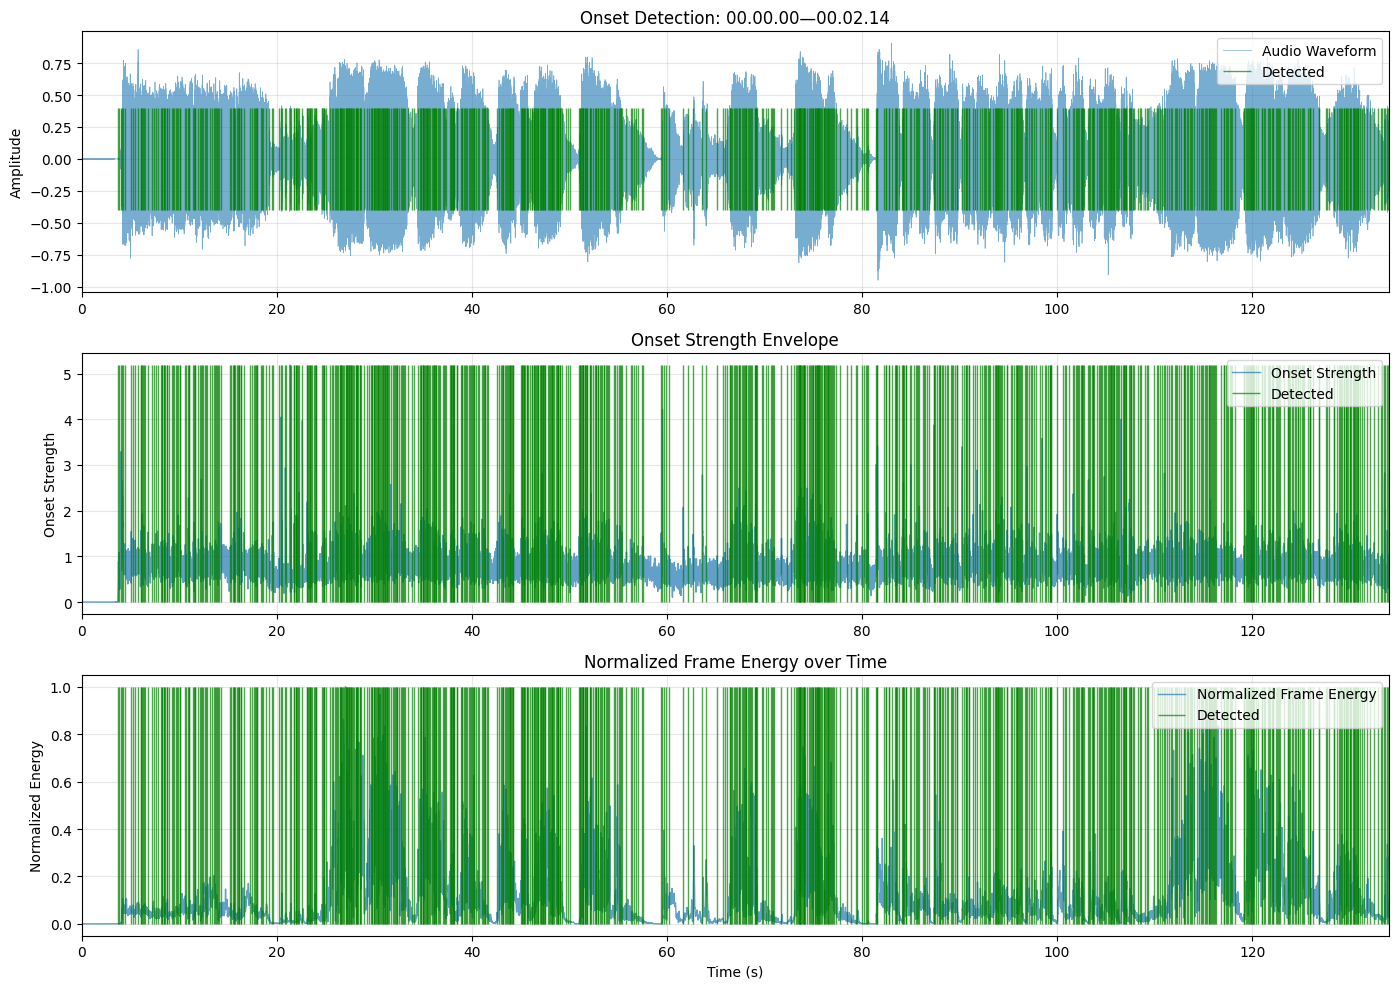


✓ Visualization saved to: d:\Honours project\ML-based-analysis-of-sound\onset_detection_analysis.png


In [18]:
# Visualization
print("\n" + "="*60)
print("STEP 9: VISUALIZE ONSET DETECTION RESULTS")
print("="*60)

# Recompute onset envelope and energy for visualization
onset_env_vis = librosa.onset.onset_strength(y=y_detect, sr=sr_detect)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Time axis
times = np.arange(len(y_detect)) / sr_detect

# Plot 1: Waveform
ax = axes[0]
ax.plot(times, y_detect, alpha=0.6, linewidth=0.5, label='Audio Waveform')
ax.vlines(onsets_time_final, -0.4, 0.4, colors='green', alpha=0.7, linewidth=1.0, label='Detected')
ax.set_ylabel('Amplitude')
ax.set_title(f'Onset Detection: {audio_file.stem}')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(y_detect) / sr_detect)

# Plot 2: Onset strength
ax = axes[1]
x_frames = librosa.frames_to_time(np.arange(len(onset_env_vis)), sr=sr_detect)
ax.plot(x_frames, onset_env_vis, alpha=0.7, linewidth=1, label='Onset Strength')
ax.vlines(onsets_time_final, 0, max(onset_env_vis), colors='green', alpha=0.7, linewidth=1.0, label='Detected')
ax.set_ylabel('Onset Strength')
ax.set_title('Onset Strength Envelope')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(y_detect) / sr_detect)

# Plot 3: Frame energy
ax = axes[2]
hop_length = 512
x_energy = librosa.frames_to_time(np.arange(len(frame_energy_norm)), sr=sr_detect, hop_length=hop_length)
ax.plot(x_energy, frame_energy_norm, alpha=0.7, linewidth=1, label='Normalized Frame Energy')
ax.vlines(onsets_time_final, 0, 1, colors='green', alpha=0.7, linewidth=1.0, label='Detected')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Normalized Energy')
ax.set_title('Normalized Frame Energy over Time')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(y_detect) / sr_detect)

plt.tight_layout()
plt.savefig(str(repo_root / 'onset_detection_analysis.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: {repo_root / 'onset_detection_analysis.png'}")

In [19]:
# STEP 10: Generate onset/offset labels by energy segments
# Rule: find low-energy boundaries, then pair each segment's FIRST onset with segment end.
print("\n" + "=" * 60)
print("STEP 10: GENERATE ONSET/OFFSET FROM ENERGY SEGMENTS")
print("=" * 60)

# Output paths
onset_labels_dir = repo_root / "data" / "onset_labels"
onset_labels_dir.mkdir(parents=True, exist_ok=True)

label_txt_path = onset_labels_dir / f"{audio_file.stem}.txt"
label_csv_path = onset_labels_dir / f"{audio_file.stem}_draft.csv"

# 1) Onset candidates
onset_frames_draft = librosa.onset.onset_detect(
    y=y_detect,
    sr=sr_detect,
    units="frames",
    pre_max=20,
    post_max=20,
    pre_avg=100,
    post_avg=100,
    delta=0.20,
    wait=20,
)
onset_times_draft = librosa.frames_to_time(onset_frames_draft, sr=sr_detect)

# 2) Frame-wise energy
hop_length = 512
rms_energy = librosa.feature.rms(y=y_detect, frame_length=2048, hop_length=hop_length)[0]
rms_norm = rms_energy / (np.max(rms_energy) + 1e-12)

# 3) Energy thresholding to identify low-energy separators
energy_floor = np.percentile(rms_norm, 30)
energy_margin = 0.06
low_energy_threshold = min(0.25, float(energy_floor + energy_margin))

# low-energy mask: True means low-energy frame
low_mask = rms_norm < low_energy_threshold

# Keep only sustained low-energy runs (remove tiny dips)
min_low_run_frames = 8  # ~85ms at 48k/512
low_mask_clean = np.zeros_like(low_mask, dtype=bool)
start = None
for i, v in enumerate(low_mask):
    if v and start is None:
        start = i
    if (not v or i == len(low_mask) - 1) and start is not None:
        end = i if not v else i + 1
        if end - start >= min_low_run_frames:
            low_mask_clean[start:end] = True
        start = None

# high-energy segments are complement of sustained low-energy runs
high_mask = ~low_mask_clean

# Extract contiguous high-energy segments
segments = []
start = None
for i, v in enumerate(high_mask):
    if v and start is None:
        start = i
    if (not v or i == len(high_mask) - 1) and start is not None:
        end = i if not v else i + 1
        if end - start >= 3:  # ignore very short fragments
            segments.append((start, end - 1))
        start = None

# 4) For each segment: onset = FIRST onset inside segment, offset = segment end
onset_frames_all = librosa.time_to_frames(onset_times_draft, sr=sr_detect, hop_length=hop_length)

draft_rows = []
for seg_start_f, seg_end_f in segments:
    idx = np.where((onset_frames_all >= seg_start_f) & (onset_frames_all <= seg_end_f))[0]
    if len(idx) == 0:
        continue

    first_onset_f = int(onset_frames_all[idx[0]])
    onset_t = float(librosa.frames_to_time(first_onset_f, sr=sr_detect, hop_length=hop_length))
    offset_t = float(librosa.frames_to_time(seg_end_f, sr=sr_detect, hop_length=hop_length))

    # Safety guard
    if offset_t <= onset_t:
        offset_t = onset_t + 0.06

    # Count ignored intermediate onsets in this segment
    ignored = max(0, len(idx) - 1)
    draft_rows.append((onset_t, offset_t, ignored, seg_start_f, seg_end_f))

# 5) Save outputs
with open(label_txt_path, "w", encoding="utf-8") as f:
    for onset_t, offset_t, _, _, _ in draft_rows:
        f.write(f"{onset_t:.3f} {offset_t:.3f}\n")

with open(label_csv_path, "w", encoding="utf-8") as f:
    f.write("onset_sec,offset_sec,duration_sec,ignored_inner_onsets,seg_start_frame,seg_end_frame,source,note\n")
    for onset_t, offset_t, ignored, seg_s, seg_e in draft_rows:
        dur = offset_t - onset_t
        f.write(f"{onset_t:.3f},{offset_t:.3f},{dur:.3f},{ignored},{seg_s},{seg_e},{source_to_detect},energy_segment_first_onset\n")

total_ignored = sum(r[2] for r in draft_rows)
print(f"Onset candidates: {len(onset_times_draft)}")
print(f"Energy floor (p30): {energy_floor:.3f}")
print(f"Low-energy threshold: {low_energy_threshold:.3f}")
print(f"High-energy segments: {len(segments)}")
print(f"Final onset/offset pairs: {len(draft_rows)}")
print(f"Ignored intermediate onsets: {total_ignored}")
print(f"\nTXT saved: {label_txt_path}")
print(f"CSV saved: {label_csv_path}")
print("\nRule applied: each segment keeps ONLY the first onset; segment end is the offset.")


STEP 10: GENERATE ONSET/OFFSET FROM ENERGY SEGMENTS
Onset candidates: 72
Energy floor (p30): 0.279
Low-energy threshold: 0.250
High-energy segments: 48
Final onset/offset pairs: 22
Ignored intermediate onsets: 35

TXT saved: d:\Honours project\ML-based-analysis-of-sound\data\onset_labels\00.00.00—00.02.14.txt
CSV saved: d:\Honours project\ML-based-analysis-of-sound\data\onset_labels\00.00.00—00.02.14_draft.csv

Rule applied: each segment keeps ONLY the first onset; segment end is the offset.
